Importing the Dependencies

In [125]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Data Collection and Analysis

PIMA Diabetes Dataset

In [126]:
# loading the diabetes dataset to a pandas DataFrame
diabetes_dataset = pd.read_csv('C:\\Users\\visha\\OneDrive\\Desktop\\projects\\Multiple_Heath_Disease_Predictor\\dataset\\diabetes.csv') 

In [127]:
# printing the first 5 rows of the dataset
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [128]:
# number of rows and Columns in this dataset
diabetes_dataset.shape

(768, 9)

In [129]:
# getting the statistical measures of the data
diabetes_dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

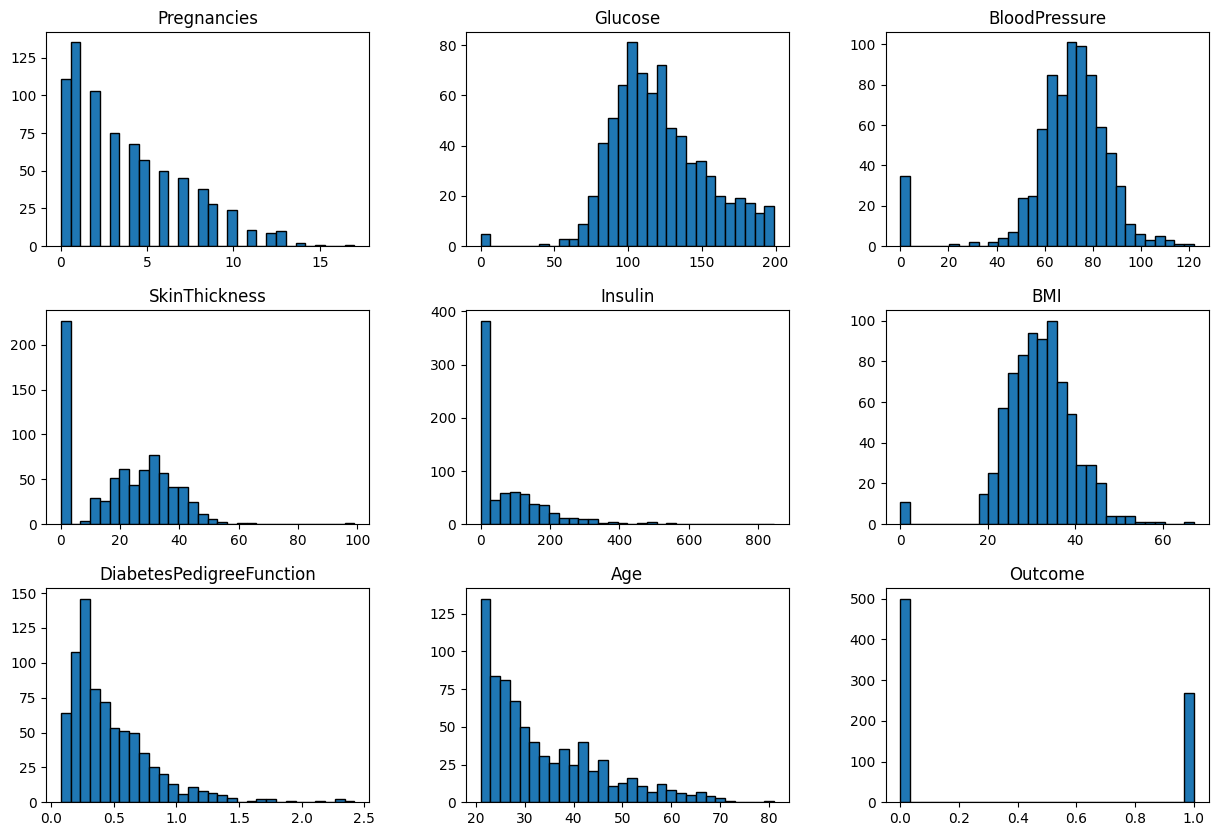

In [130]:
diabetes_dataset.hist(bins=30, figsize=(15, 10), edgecolor='black', grid=False)

In [131]:
diabetes_dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [132]:
diabetes_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [133]:
# separating the data and labels
X = diabetes_dataset.drop(columns = 'Outcome', axis=1)
Y = diabetes_dataset['Outcome']

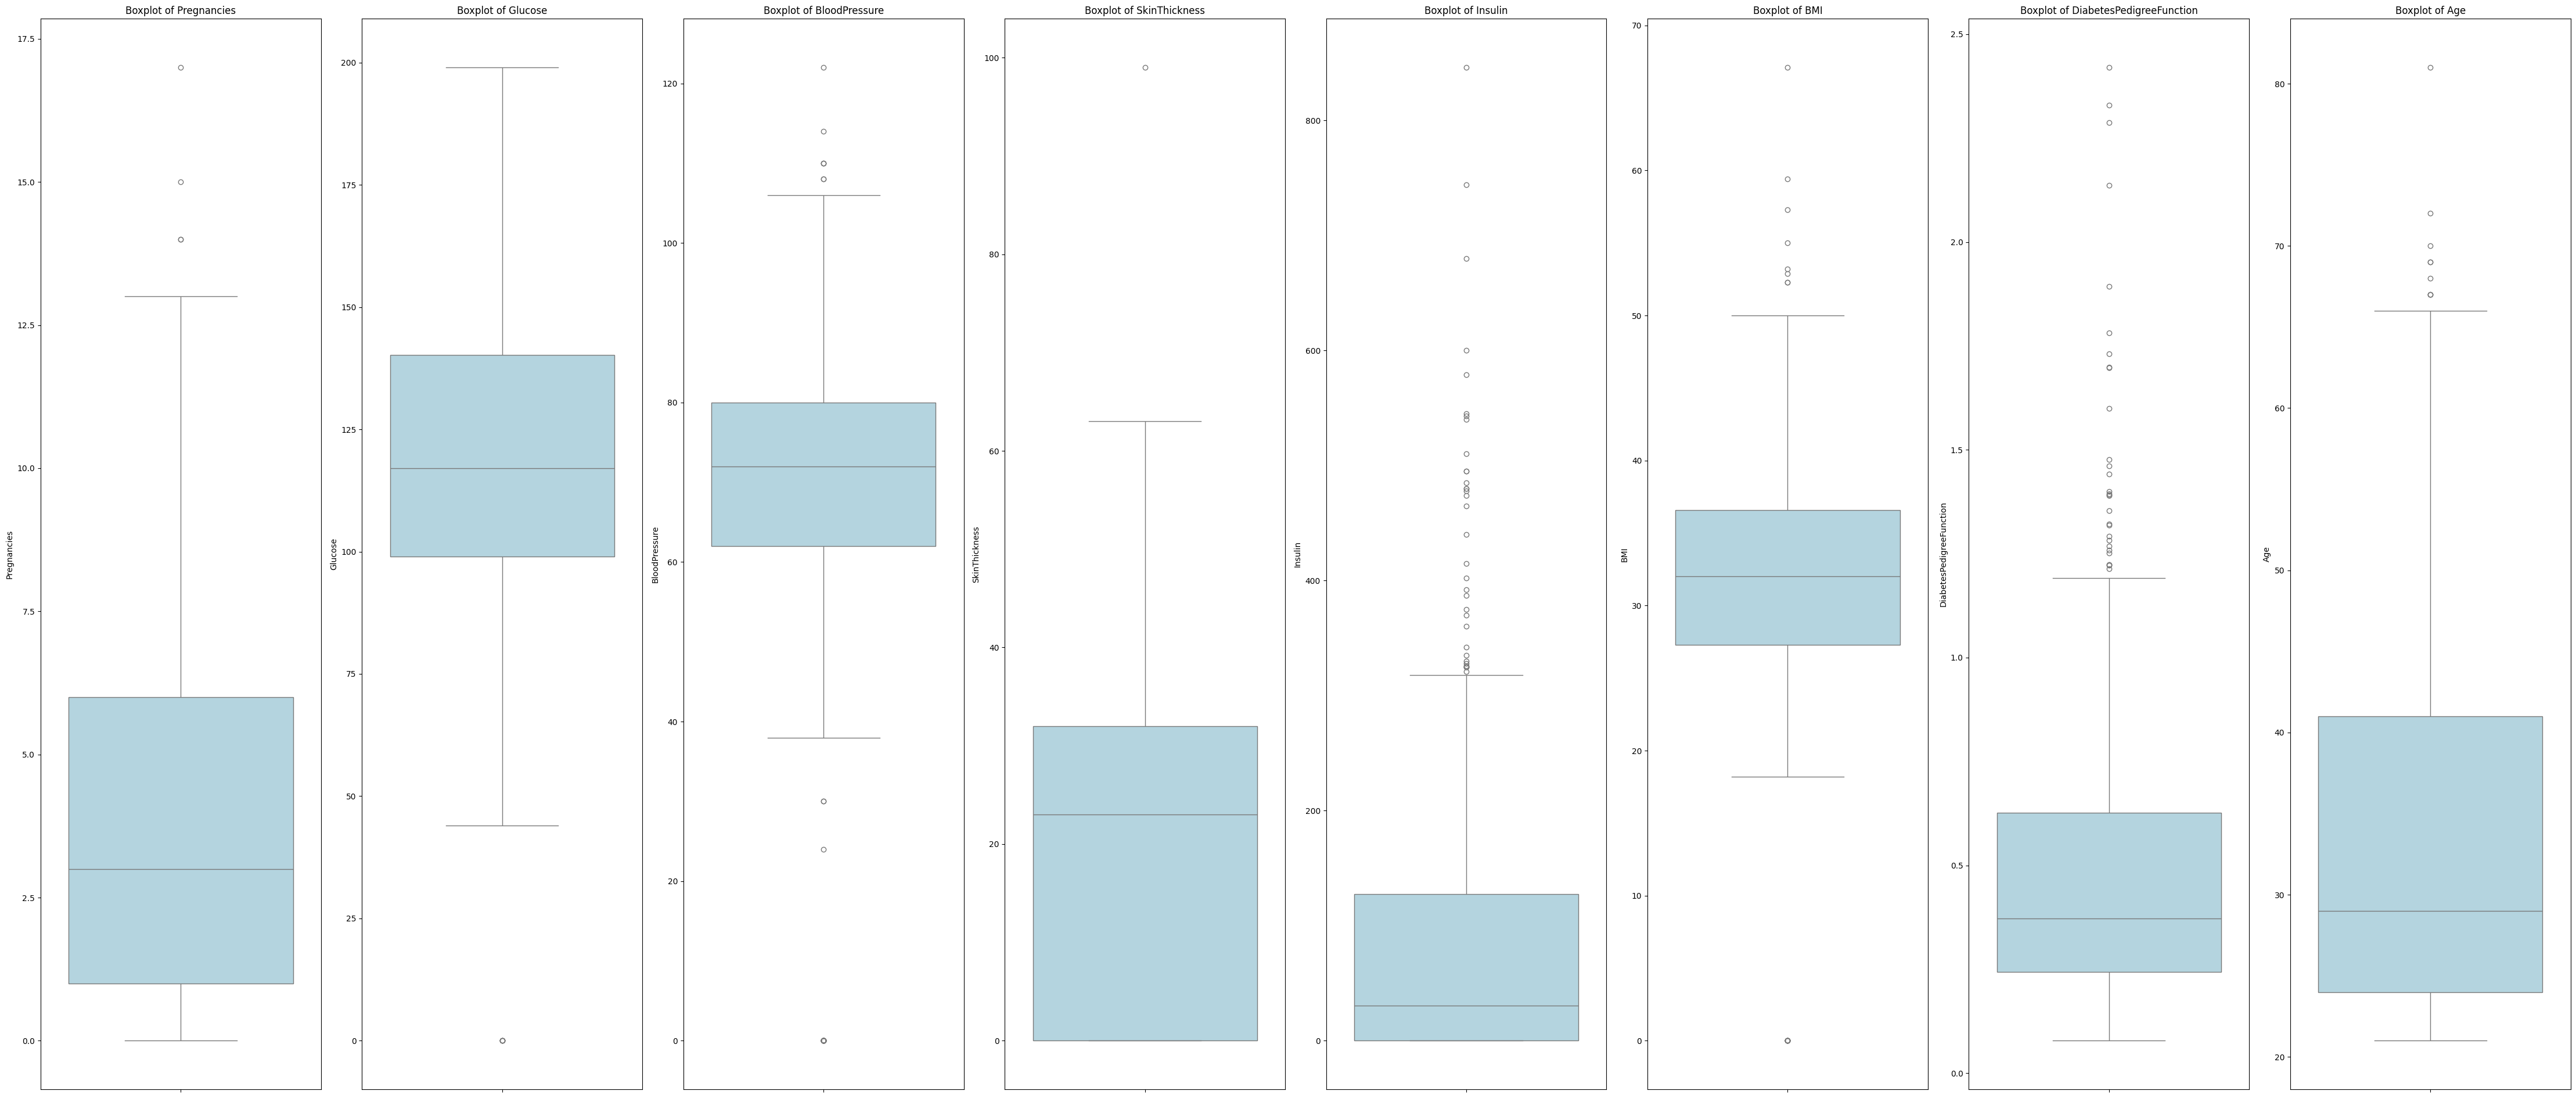

In [134]:
plt.figure(figsize=(50, 19))
for i, col in enumerate(X.columns):
    plt.subplot(1, 9, i + 1)
    sns.boxplot(y=X[col], color='lightblue')
    plt.title(f'Boxplot of {col}')
    plt.xlabel('')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [135]:
def IQR(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    out = data[(data[col] < low) | (data[col] > high)]
    return len(out), low, high

for col in X.columns:
    length, low, high = IQR(X, col)
    print(f'Total number of outliers: {length}. For columns: {col}')
    # print(f'25th percintle: {low} and 75th percintle: {high}')

Total number of outliers: 4. For columns: Pregnancies
Total number of outliers: 5. For columns: Glucose
Total number of outliers: 45. For columns: BloodPressure
Total number of outliers: 1. For columns: SkinThickness
Total number of outliers: 34. For columns: Insulin
Total number of outliers: 19. For columns: BMI
Total number of outliers: 29. For columns: DiabetesPedigreeFunction
Total number of outliers: 9. For columns: Age


Train Test Split

In [136]:
def remove_outliers_clip(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return data[col].clip(lower=low, upper=high)

In [137]:
for col in X.columns:
    X[col] = remove_outliers_clip(X, col)

In [138]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer

In [139]:
cols_with_missing_zeros = [1, 2, 3, 4, 5] 

cols_valid_zeros = [0, 6, 7]

zero_imputation_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(missing_values=0, strategy='median')), 
    ('scaler', RobustScaler())
])

standard_pipeline = Pipeline(steps=[
    ('scaler', RobustScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('fix_zeros', zero_imputation_pipeline, cols_with_missing_zeros),
        ('standard', standard_pipeline, cols_valid_zeros)
    ],
    remainder='drop'
)


Training the Model

In [140]:
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import precision_recall_curve

In [141]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, stratify=Y, random_state=2)

In [142]:
model_1 = CatBoostClassifier(auto_class_weights='Balanced', iterations=1000)

est_1 = Pipeline([
    ('preprocessor', preprocessor),
    ('est', model_1)
])

est_1.fit(X_train, y_train)

Learning rate set to 0.008365
0:	learn: 0.6893426	total: 6.27ms	remaining: 6.26s
1:	learn: 0.6863586	total: 8.17ms	remaining: 4.08s
2:	learn: 0.6829726	total: 9.58ms	remaining: 3.18s
3:	learn: 0.6790394	total: 11.7ms	remaining: 2.92s
4:	learn: 0.6751950	total: 13.2ms	remaining: 2.63s
5:	learn: 0.6712941	total: 14.8ms	remaining: 2.44s
6:	learn: 0.6675427	total: 16.3ms	remaining: 2.31s
7:	learn: 0.6631658	total: 20.7ms	remaining: 2.57s
8:	learn: 0.6601889	total: 23.1ms	remaining: 2.54s
9:	learn: 0.6575846	total: 24.4ms	remaining: 2.41s
10:	learn: 0.6549485	total: 26.1ms	remaining: 2.35s
11:	learn: 0.6517994	total: 28.1ms	remaining: 2.31s
12:	learn: 0.6480159	total: 29.6ms	remaining: 2.25s
13:	learn: 0.6450389	total: 31.3ms	remaining: 2.2s
14:	learn: 0.6413170	total: 33ms	remaining: 2.17s
15:	learn: 0.6381066	total: 34.5ms	remaining: 2.12s
16:	learn: 0.6350531	total: 35.9ms	remaining: 2.08s
17:	learn: 0.6319211	total: 37.4ms	remaining: 2.04s
18:	learn: 0.6289048	total: 38.8ms	remaining: 2

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('fix_zeros',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(missing_values=0,
                                                                                 strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  [1, 2, 3, 4, 5]),
                                                 ('standard',
                                                  Pipeline(steps=[('scaler',
                                                                   RobustScaler())]),
                                                  [0, 6, 7])])),
                ('est',
                 <catboost.core.CatBoostClassifier object at 0x00000215033245D0>)])

Model Evaluation

Accuracy Score

In [143]:
model_2 = XGBClassifier(scale_pos_weight=10)

est_2 = Pipeline([
    ('preporcessor', preprocessor),
    ('est', model_2)
])

est_2.fit(X_train, y_train)

Pipeline(steps=[('preporcessor',
                 ColumnTransformer(transformers=[('fix_zeros',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(missing_values=0,
                                                                                 strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  [1, 2, 3, 4, 5]),
                                                 ('standard',
                                                  Pipeline(steps=[('scaler',
                                                                   RobustScaler())]),
                                                  [0, 6, 7])])),
                ('est',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=Non...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [144]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Generates a comprehensive evaluation dashboard for a classification model.
    Arguments:
        model: Trained estimator (or pipeline)
        X_test: Test features
        y_test: Test labels
        model_name: String name for the plot labels
    """
    
    # 1. Get Predictions
    # We need hard classes (0/1) for the Matrix/Report
    y_pred = model.predict(X_test)
    # We need probabilities for Log Loss and PR Curve
    y_proba = model.predict_proba(X_test)[:, 1] 

    # 2. Print Text Metrics
    print(f"--- {model_name} Evaluation ---")
    print(f"Log Loss: {log_loss(y_test, y_proba):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # 3. Generate Plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Plot Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test, 
        y_pred, 
        ax=ax1, 
        cmap='Blues', 
        colorbar=False
    )
    ax1.set_title("Confusion Matrix")

    # Plot Precision-Recall Curve
    # (Crucial for your unbalanced 'Outcome' data)
    PrecisionRecallDisplay.from_predictions(
        y_test, 
        y_proba, 
        ax=ax2, 
        name=model_name,
        plot_chance_level=True # Adds the baseline for context
    )
    ax2.set_title("Precision-Recall Curve")
    ax2.grid(linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# --- Usage ---
# Assuming you have already split your data:
# evaluate_model(est_1, X_test, y_test)

--- CatBoostClassifier Evaluation ---
Log Loss: 0.5383

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80       100
           1       0.63      0.63      0.63        54

    accuracy                           0.74       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.74      0.74       154



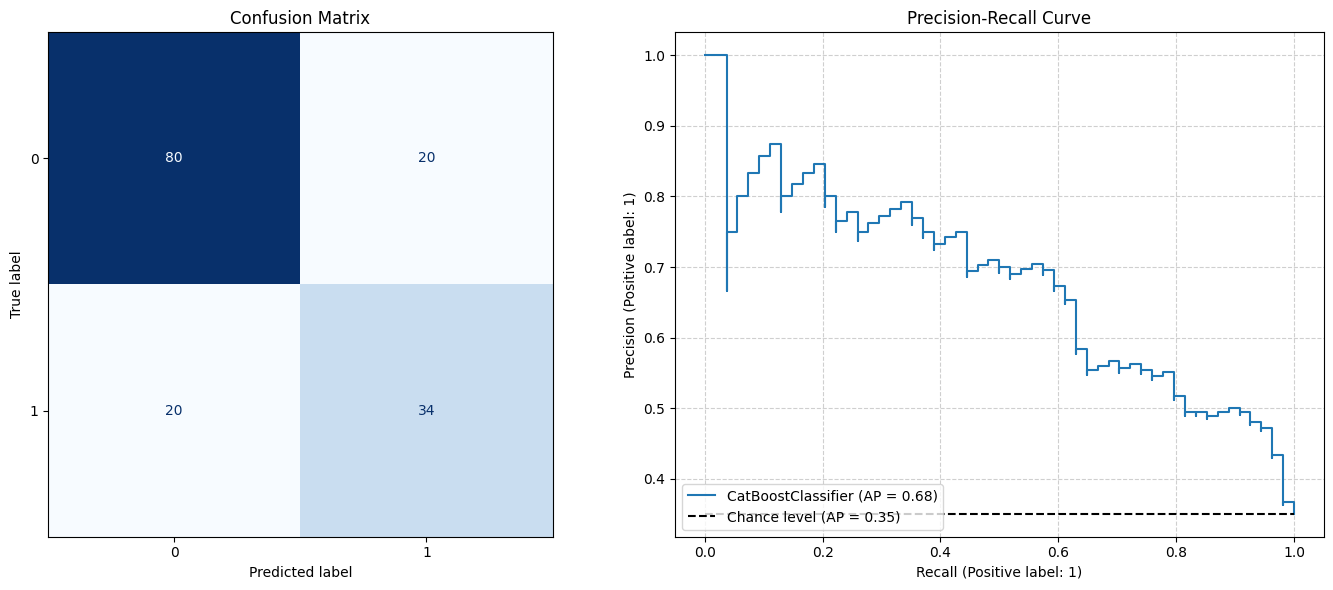

In [145]:
evaluate_model(model=est_1, X_test=X_test, y_test=y_test, model_name="CatBoostClassifier")

--- XGBoostClassifier Evaluation ---
Log Loss: 0.8074

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.78      0.80       100
           1       0.63      0.69      0.65        54

    accuracy                           0.75       154
   macro avg       0.72      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



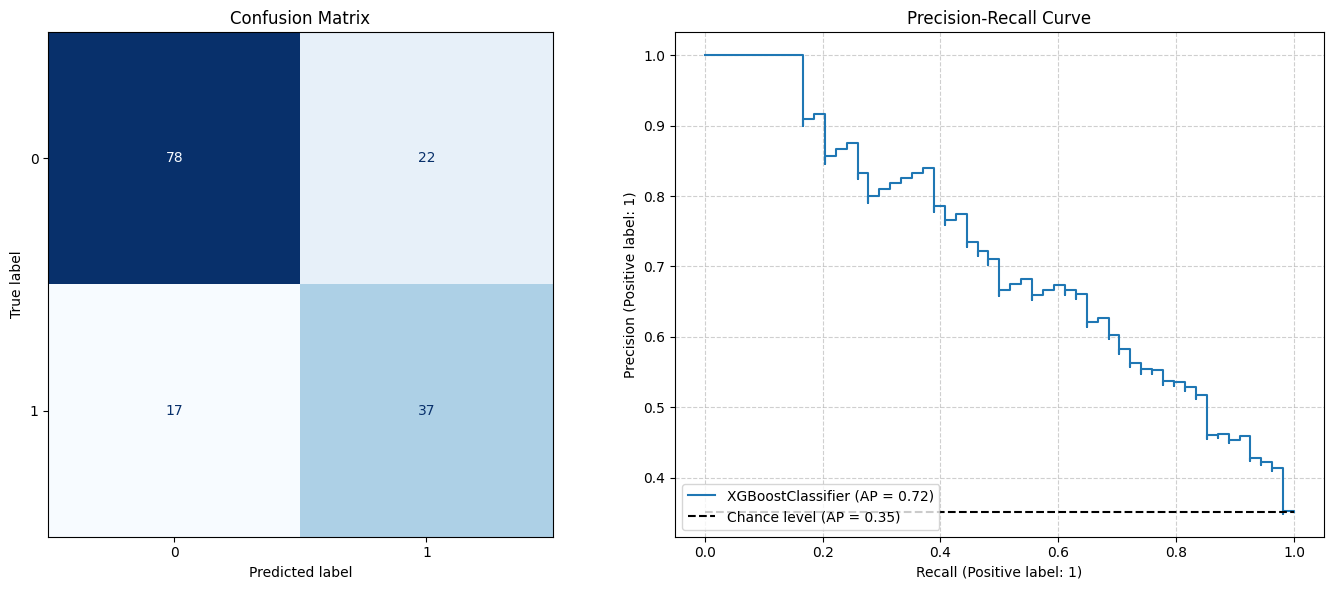

In [146]:
evaluate_model(model=est_2, X_test=X_test, y_test=y_test, model_name="XGBoostClassifier")

In [147]:
model = CatBoostClassifier(auto_class_weights='Balanced', iterations=1000)

est = Pipeline([
    ('preprocessor', preprocessor),
    ('est', model_1)
])

est.fit(X, Y)

Learning rate set to 0.009204
0:	learn: 0.6888818	total: 1.63ms	remaining: 1.63s
1:	learn: 0.6852566	total: 2.86ms	remaining: 1.43s
2:	learn: 0.6819937	total: 4.09ms	remaining: 1.36s
3:	learn: 0.6779569	total: 5.46ms	remaining: 1.36s
4:	learn: 0.6739532	total: 6.96ms	remaining: 1.39s
5:	learn: 0.6697460	total: 8.79ms	remaining: 1.46s
6:	learn: 0.6660221	total: 10.7ms	remaining: 1.52s
7:	learn: 0.6622127	total: 12.5ms	remaining: 1.55s
8:	learn: 0.6586828	total: 14.2ms	remaining: 1.57s
9:	learn: 0.6563317	total: 16ms	remaining: 1.58s
10:	learn: 0.6524107	total: 17.6ms	remaining: 1.58s
11:	learn: 0.6489610	total: 19.2ms	remaining: 1.58s
12:	learn: 0.6457195	total: 20.7ms	remaining: 1.57s
13:	learn: 0.6425519	total: 22.1ms	remaining: 1.55s
14:	learn: 0.6398984	total: 23.7ms	remaining: 1.56s
15:	learn: 0.6368201	total: 25.3ms	remaining: 1.56s
16:	learn: 0.6340984	total: 26.9ms	remaining: 1.55s
17:	learn: 0.6305771	total: 28.4ms	remaining: 1.55s
18:	learn: 0.6271530	total: 29.9ms	remaining: 

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('fix_zeros',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(missing_values=0,
                                                                                 strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  [1, 2, 3, 4, 5]),
                                                 ('standard',
                                                  Pipeline(steps=[('scaler',
                                                                   RobustScaler())]),
                                                  [0, 6, 7])])),
                ('est',
                 <catboost.core.CatBoostClassifier object at 0x00000215033245D0>)])

Making a Predictive System

In [148]:
input_data = (5,166,72,19,175,25.8,0.587,51)

# changing the input_data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = est.predict(input_data_reshaped)
print(prediction)

if (prediction[0] == 0):
  print('The person is not diabetic')
else:
  print('The person is diabetic')

[1]
The person is diabetic


c:\Users\visha\OneDrive\Desktop\projects\Multiple_Heath_Disease_Predictor\myenv\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  
c:\Users\visha\OneDrive\Desktop\projects\Multiple_Heath_Disease_Predictor\myenv\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  


Saving the trained model

In [149]:
import pickle

In [151]:
filename = 'C:\\Users\\visha\\OneDrive\\Desktop\\projects\\Multiple_Heath_Disease_Predictor\\application\\saved_models\\diabetes_model.sav'
pickle.dump(est, open(filename, 'wb'))